In [27]:
# 1D 합성곱 연산의 구현

import numpy as np

def conv1d(x, w, p=0, s=1):
    w_rot = np.array(w[::-1])
    x_padded = np.array(x)
    if p > 0:
        zero_pad = np.zeros(shape=p)
        x_padded = np.concatenate([zero_pad, x_padded, zero_pad])
    
    result = []
    
    for i in range(0, int(len(x) / s), s):
        result.append(np.sum(x_padded[i:i+w_rot.shape[0]] * w_rot))
    
    return np.array(result)

x = [1, 3, 2, 4, 5, 6, 1, 3]
w = [1, 0, 3, 1, 2]

print("Conv1d 구현: ", conv1d(x, w, p=2, s=1))

# 넘파이 convolve 연산과 비교

print("넘파이 convolve: ", np.convolve(x, w, mode='same'))

Conv1d 구현:  [ 5. 14. 16. 26. 24. 34. 19. 22.]
넘파이 convolve:  [ 5 14 16 26 24 34 19 22]


In [28]:
# 이번엔 2d conv 합성곱 구현

import scipy.signal

def conv2d(X, W, p=(0,0), s=(1,1)):
    W_rot = np.array(W)[::-1, ::-1] # rotation은 transpose와 다르다는걸 명심
    X_origin = np.array(X)
    
    n1 = X_origin.shape[0] + 2 * p[0]
    n2 = X_origin.shape[1] + 2 * p[1]
    
    X_padded = np.zeros(shape=(n1, n2))
    X_padded[p[0]:p[0]+X_origin.shape[0], p[1]:p[1]+X_origin.shape[1]] = X_origin
    
    result = []
    
    for i in range(0, int((X_padded.shape[0] - W_rot.shape[0]) / s[0]) + 1, s[0]):
       result.append([])
       
       for j in range(0, int((X_padded.shape[1] - W_rot.shape[1]) / s[1]) + 1, s[1]):
           X_sub = X_padded[i:i+W_rot.shape[0], j:j+W_rot.shape[1]]
           result[-1].append(np.sum(X_sub * W_rot))
           
    return np.array(result)

X = [[1, 3, 2, 4], [5, 6, 1, 3], [1 , 2,0, 2], [3, 4, 3, 2]]
W = [[1, 0, 3], [1, 2, 1], [0, 1, 1]]
print('Conv2d 구현: \n', 
      conv2d(X, W, p=(1,1), s=(1,1)))

print('싸이파이 결과: \n', 
      scipy.signal.convolve2d(X, W, mode='same'))

Conv2d 구현: 
 [[11. 25. 32. 13.]
 [19. 25. 24. 13.]
 [13. 28. 25. 17.]
 [11. 17. 14.  9.]]
싸이파이 결과: 
 [[11 25 32 13]
 [19 25 24 13]
 [13 28 25 17]
 [11 17 14  9]]


In [29]:
### CNN을 돌리기 위한 이미지 적재하기

### 압축 해제 코드
import sys
import gzip
import shutil
import os

if (sys.version_info > (3, 0)):
    writemode = 'wb'
else:
    writemode = 'w'

zipped_mnist = [f for f in os.listdir('./') if f.endswith('ubyte.gz')]
for z in zipped_mnist:
    with gzip.GzipFile(z, mode='rb') as decompressed, open(z[:-3], writemode) as outfile:
        outfile.write(decompressed.read()) 
        

### 데이터 불러오는 함수 정의
import os
import struct
import numpy as np
 
def load_mnist(path, kind='train'):
    """`path`에서 MNIST 데이터 불러오기"""
    labels_path = os.path.join(path, 
                               '%s-labels-idx1-ubyte' % kind)
    images_path = os.path.join(path, 
                               '%s-images-idx3-ubyte' % kind)
        
    with open(labels_path, 'rb') as lbpath:
        magic, n = struct.unpack('>II', 
                                 lbpath.read(8))
        labels = np.fromfile(lbpath, 
                             dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        magic, num, rows, cols = struct.unpack(">IIII", 
                                               imgpath.read(16))
        images = np.fromfile(imgpath, 
                             dtype=np.uint8).reshape(len(labels), 784)
        images = ((images / 255.) - .5) * 2 # gradient를 사용하기 때문에 픽셀 단위로 정규화를 해줌.
 
    return images, labels

In [30]:
### 데이터 불러오기

X_data, y_data = load_mnist('', kind='train')
print('행: %d, 열: %d' % (X_data.shape[0], X_data.shape[1]))

X_test, y_test = load_mnist('', kind='t10k')
print('행: %d, 열: %d' % (X_test.shape[0], X_test.shape[1]))

X_train, y_train = X_data[:50000, :], y_data[:50000]
X_valid, y_valid = X_data[50000:, :], y_data[50000:]

print('훈련 세트: ', X_train.shape, y_train.shape)
print('검증 세트: ', X_valid.shape, y_valid.shape)
print('테스트 세트: ', X_test.shape, y_test.shape)

# 데이터 전처리
mean_vals = np.mean(X_train, axis=0)
std_vals = np.std(X_train)

X_train_centered = (X_train - mean_vals) / std_vals
X_valid_centered = (X_valid - mean_vals) / std_vals
X_test_centered = (X_test - mean_vals) / std_vals

행: 60000, 열: 784
행: 10000, 열: 784
훈련 세트:  (50000, 784) (50000,)
검증 세트:  (10000, 784) (10000,)
테스트 세트:  (10000, 784) (10000,)


In [31]:
### 데이터 차원 변경 & 원 핫 인코딩

from keras.utils import to_categorical

X_train_centered = X_train_centered.reshape((-1, 28, 28, 1))
X_valid_centered = X_valid_centered.reshape((-1, 28, 28, 1))
X_test_centered = X_test_centered.reshape((-1, 28, 28, 1))

y_train_one_hot = to_categorical(y_train)
y_valid_one_hot = to_categorical(y_valid)
y_test_one_hot = to_categorical(y_test)

print(y_train[0], y_train_one_hot[0])


5 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [59]:
### 케라스를 이용하여 CNN 구현하기

from keras import layers, models

model = models.Sequential()

model.add(layers.Input(shape=(28,28,1)))
model.add(layers.Conv2D(32, (5, 5), padding='valid', activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64, (5,5), padding='valid', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(1024, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

c:\Users\조승현\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,111,946 (4.24 MB)

 Trainable params: 1,111,946 (4.24 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
### 모델 컴파일

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [ ]:
### 텐서보드를 이용해보기

import time
from keras.callbacks import TensorBoard, ModelCheckpoint

#callback_list = [ModelCheckpoint(filepath='cnn_checkpoint.h5', monitor='val_loss', save_best_only=True)]

In [61]:
### 모델 훈련

history = model.fit(X_train_centered, y_train_one_hot, batch_size=64, epochs=20,
                    validation_data=(X_valid_centered, y_valid_one_hot))

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - acc: 0.9575 - loss: 0.1363 - val_acc: 0.9891 - val_loss: 0.0400
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - acc: 0.9843 - loss: 0.0489 - val_acc: 0.9853 - val_loss: 0.0494
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - acc: 0.9887 - loss: 0.0360 - val_acc: 0.9866 - val_loss: 0.0513
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - acc: 0.9918 - loss: 0.0262 - val_acc: 0.9897 - val_loss: 0.0413
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - acc: 0.9923 - loss: 0.0247 - val_acc: 0.9902 - val_loss: 0.0399
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - acc: 0.9937 - loss: 0.0211 - val_acc: 0.9906 - val_loss: 0.0404
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - acc: 0.9942 - loss: 0.0171 - val_acc: 0.9903 - val_loss: 0.0419
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - acc: 0.9949 - loss: 0.0167 - val_acc: 0.9907 - val_loss: 0.0453
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 

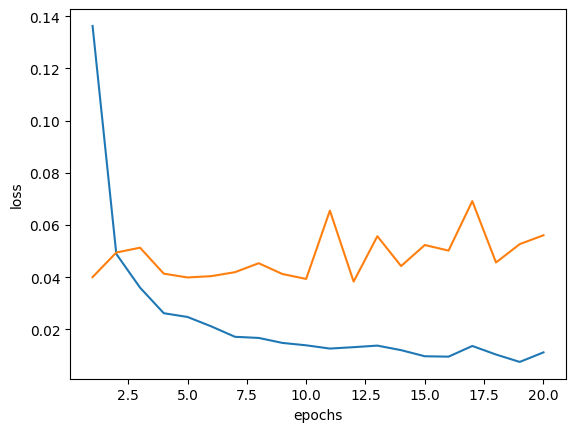

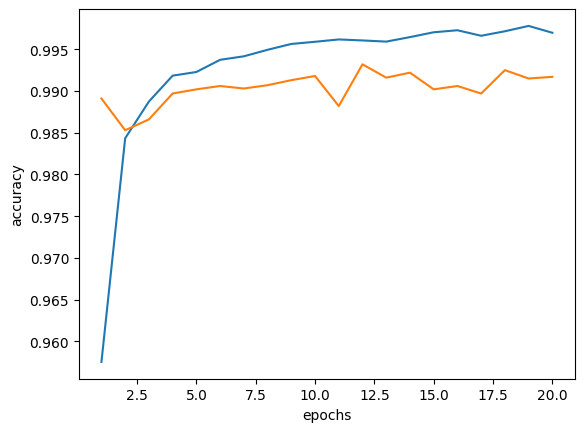

In [62]:
### 손실 그래프 그려보기

import matplotlib.pyplot as plt

epochs = np.arange(1, 21)
plt.plot(epochs, history.history['loss'])
plt.plot(epochs, history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

# 그래프의 결과를 보면 epoch 5부터 vaildation set의 loss가 점차 증가하는걸 볼 수 있음.
# Overfitting이 걸렸다는거임.

### 정확도 그래프
plt.plot(epochs, history.history['acc'])
plt.plot(epochs, history.history['val_acc'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show() 

# 정확도 그래프를 봐도 epoch 5정도부터 점점 정확도가 떨어지는걸 볼 수 있음.

In [63]:
### 모델 평가

model.predict(X_test_centered)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[5.4746704e-27, 6.2944671e-25, 6.6803461e-23, ..., 1.0000000e+00,
        1.9441110e-26, 7.2471445e-20],
       [3.3004150e-26, 4.2005047e-28, 1.0000000e+00, ..., 1.2274888e-32,
        1.5920006e-25, 1.6551657e-33],
       [3.5542400e-18, 1.0000000e+00, 1.8381254e-14, ..., 1.1594148e-14,
        2.7514224e-14, 1.3774721e-18],
       ...,
       [5.0069884e-33, 4.8567188e-25, 2.5935828e-32, ..., 1.9081343e-30,
        8.1672882e-28, 4.8819899e-29],
       [1.3930539e-28, 4.1105065e-33, 1.4311796e-35, ..., 4.9233540e-31,
        1.9313952e-20, 1.9822629e-29],
       [1.8688361e-17, 3.7592418e-18, 3.7846560e-16, ..., 4.1029623e-22,
        4.2098004e-17, 1.5252862e-19]], shape=(10000, 10), dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


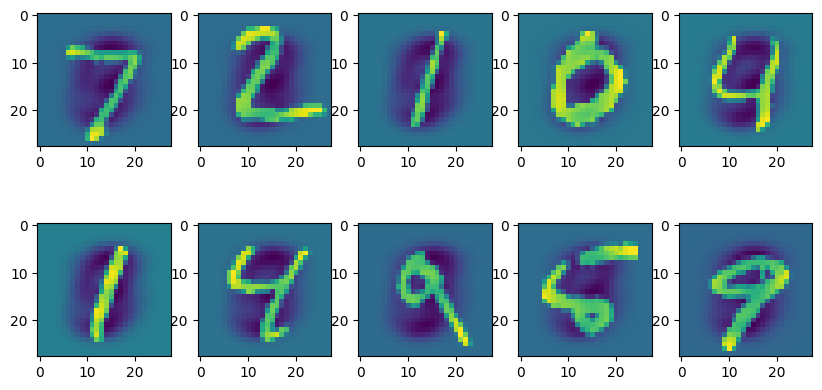

In [64]:
### 모델 복원

from keras.models import load_model
import matplotlib.pyplot as plt

#model.save("cnn_model.h5")
#restored_model = load_model("cnn_model.h5")

#restored_model.evaluate(X_test_centered, y_test_one_hot)

#print(np.argmax(restored_model.predict(X_test_centered[:10]), axis=1))
print(np.argmax(model.predict(X_test_centered[:10]), axis=1))
print(y_test[:10])

# 모두 정답!
# 전 챕터에서 했던 MLP모델은 97% 정도의 정확도를 얻었다면 CNN모델은 그것보다 훨씬 뛰어난 99.1% 정도의 정확도를 얻었음.

### 모델이 정답으로 예측했던것과 한번 실제 사진 출력해보기

fig = plt.figure(figsize = (10, 5))
for i in range(10):
    fig.add_subplot(2, 5, i+1)
    plt.imshow(X_test_centered[i].reshape(28,28))

In [ ]:
### 첫번째 conv층 출력(feature map) 시각화해보기

first_layer = model.layers[0]
print(first_layer) # 첫번째 층이 Conv2D층이란걸 알 수 있음.
print(model.input)

first_activation = models.Model(inputs=model.input, output=first_layer.output)
activation = first_activation.predict(X_test_centered[:10])

print(activation.shape) 

fig = plt.figure(figsize = (10, 15)) # 필터가 32개니까 첫번째 필터를 거친 특성맵을 한번 출력해보기
for i in range(32):
    fig.add_subplot(7, 5, i+1)
    plt.imshow(activation[0, :, :, i])